In [2]:
import pandas as pd
import random
from datetime import datetime, timedelta

# This is our "Robot" generating data for an Indian brand
products = ["Matte Crayon Lipstick", "Ace Foundation Stick", "Vitamin C Serum", "Kohl Pencil"]
raw_list = []

for i in range(50):
    p = random.choice(products)
    raw_list.append({
        "SKU_ID": f"SUG-{p[:3].upper()}-{random.randint(100,999)}",
        "Product": p,
        "Price": f"₹{random.choice([799, 1299, 599, 499])}", # Price with symbol
        "MFG_Date": (datetime.now() - timedelta(days=random.randint(100, 600))).strftime("%d/%m/%Y"),
        "Warehouse": random.choice(["Bengaluru-Hub", "Mumbai-North", None]) # Some are 'None' (missing)
    })

# Save it to the Bronze folder
df_bronze = pd.DataFrame(raw_list)
df_bronze.to_csv('1_Bronze_Raw/inventory_raw.csv', index=False)

print("created a file called 'inventory_raw.csv' in your Bronze folder.")

created a file called 'inventory_raw.csv' in your Bronze folder.


In [4]:
import pandas as pd

# Load the messy data from Bronze
df = pd.read_csv('1_Bronze_Raw/inventory_raw.csv')

# 1. Cleaning: Remove '₹' and make Price a number
df['Price'] = df['Price'].str.replace('₹', '').astype(float)

# 2. Standardization: Fix date formats so they are all the same
df['MFG_Date'] = pd.to_datetime(df['MFG_Date'], dayfirst=True)

# 3. Quality Gate: Separate the good from the bad
# If Warehouse is empty (NaN), it goes to Quarantine
quarantine = df[df['Warehouse'].isnull()]
silver_clean = df[df['Warehouse'].notnull()].copy()

# Save the cleaned data to Silver
silver_clean.to_csv('2_Silver_Cleaned/inventory_silver.csv', index=False)

# Save the 'broken' data to a log so we can see what went wrong
quarantine.to_csv('2_Silver_Cleaned/quarantine_log.csv', index=False)

print(f"Cleaned {len(silver_clean)} rows.")
print(f"Quarantined {len(quarantine)} broken rows. Check your Silver folder!")

Cleaned 34 rows.
Quarantined 16 broken rows. Check your Silver folder!


In [6]:
import pandas as pd
from datetime import datetime

# 1. Load the clean data from Silver
df = pd.read_csv('2_Silver_Cleaned/inventory_silver.csv')
df['MFG_Date'] = pd.to_datetime(df['MFG_Date'])

# 2. Logic: Assume a 2-year (24 months) shelf life for cosmetics
df['Expiry_Date'] = df['MFG_Date'] + pd.DateOffset(months=24)

# 3. Calculate how many days are left starting from TODAY
df['Days_Until_Expiry'] = (df['Expiry_Date'] - pd.Timestamp.now()).dt.days

# 4. Find the "High Risk" items (expiring in less than 6 months/180 days)
high_risk_report = df[df['Days_Until_Expiry'] < 180].copy()

# Save the final Strategy Report to Gold
high_risk_report.to_csv('3_Gold_Analytics/expiry_alerts.csv', index=False)

print(f"I found {len(high_risk_report)} products that are at risk of expiring soon.")
print("Check your Gold folder for the 'expiry_alerts.csv' file!")

I found 3 products that are at risk of expiring soon.
Check your Gold folder for the 'expiry_alerts.csv' file!


/tmp/ipykernel_208/1892230876.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


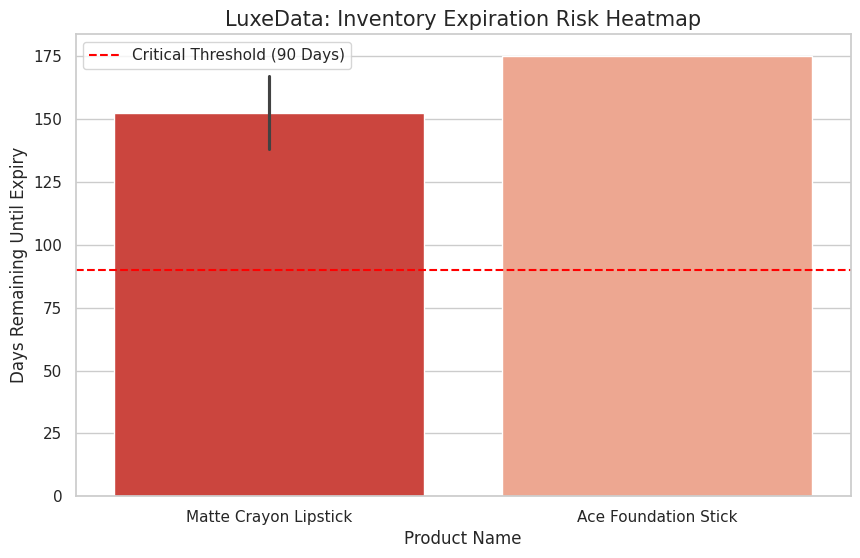

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Gold Data (The Prediction Report)
df_gold = pd.read_csv('3_Gold_Analytics/expiry_alerts.csv')

# 2. Setup the visual style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Create the Bar Chart
# We sort by Days_Until_Expiry so the most dangerous ones are first
plot = sns.barplot(
    data=df_gold.sort_values('Days_Until_Expiry'),
    x='Product',
    y='Days_Until_Expiry',
    palette='Reds_r' # Red color means "Danger/Expiry"
)

# 4. Add Labels for the Professors
plt.title('LuxeData: Inventory Expiration Risk Heatmap', fontsize=15)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Days Remaining Until Expiry', fontsize=12)
plt.axhline(90, color='red', linestyle='--', label='Critical Threshold (90 Days)')
plt.legend()

plt.show()

In [ ]:
#import requests
#from bs4 import BeautifulSoup

# This is how we get the 'Real' data
#url = "https://sugarcosmetics.com/products/matte-as-hell-crayon-lipstick"
# We 'pretend' to be a Chrome browser so we don't get blocked
#headers = {'User-Agent': 'Mozilla/5.0'}

#response = requests.get(url, headers=headers)
# Now the computer 'reads' the website
# We would then find the <span> tag that holds the price.